In [1]:
from google.colab import files
files.upload() # Click "Choose Files" and pick your kaggle.json file

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"np2010","key":"ca5455e3da8accac454ed05f937c83fe"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
# Download the dataset directly from Kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip the downloaded file
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:22<00:00, 111MB/s] 



In [4]:
import os
print(os.listdir("chest_xray"))

['chest_xray', 'test', '__MACOSX', 'train', 'val']


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os

# 1. Define image transformations (Resize, normalize, convert to tensor)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(), # Helps model generalize better
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 2. Set up folder paths (Dataset location)
data_dir = 'chest_xray'
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(data_dir, 'val'), data_transforms['val'])
}

# 3. Create DataLoaders (Feeds images to GPU in batches of 32)
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False)
}

# 4. Load Pre-trained ResNet-50 Model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 5. Modify the last layer for 2 classes (NORMAL vs PNEUMONIA)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

print(f"Model successfully loaded onto device: {device}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


Model successfully loaded onto device: cuda:0


In [6]:
# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Function
def train_model(model, criterion, optimizer, num_epochs=5):
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return model

# Run the training process for 5 epochs
trained_model = train_model(model, criterion, optimizer, num_epochs=5)

# Save the trained model weights
torch.save(trained_model.state_dict(), 'pneumonia_resnet50.pth')
print("Model saved as pneumonia_resnet50.pth")

Epoch 1/5
----------
train Loss: 0.1402 Acc: 0.9526
val Loss: 0.2418 Acc: 0.8750
Epoch 2/5
----------
train Loss: 0.0556 Acc: 0.9812
val Loss: 0.1071 Acc: 0.9375
Epoch 3/5
----------
train Loss: 0.0226 Acc: 0.9923
val Loss: 0.0813 Acc: 0.9375
Epoch 4/5
----------
train Loss: 0.0159 Acc: 0.9954
val Loss: 0.4788 Acc: 0.8125
Epoch 5/5
----------
train Loss: 0.0173 Acc: 0.9925
val Loss: 0.0492 Acc: 1.0000
Model saved as pneumonia_resnet50.pth


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=22c449707da3665c1ef9edd54c7354925069fe628f57801ada285295af9a80d1
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam


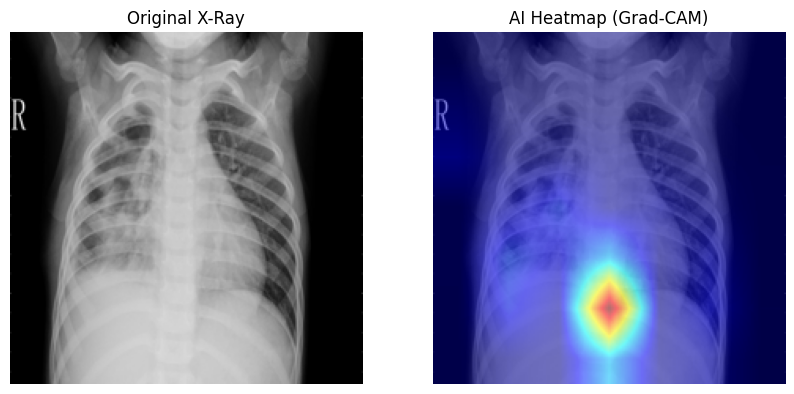

In [7]:
!pip install grad-cam

import numpy as np
import cv2
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

# 1. Target the last convolutional layer of ResNet-50
target_layers = [trained_model.layer4[-1]]
cam = GradCAM(model=trained_model, target_layers=target_layers)

# 2. Pick a single test image from the dataset
test_img_path = 'chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg' # Example image
raw_img = Image.open(test_img_path).convert('RGB')
resized_img = raw_img.resize((224, 224))

# Convert image to numpy format (0 to 1 scale)
rgb_img = np.float32(resized_img) / 255.0

# Prepare image tensor for model input
input_tensor = data_transforms['val'](raw_img).unsqueeze(0).to(device)

# 3. Generate heatmap overlay
targets = [ClassifierOutputTarget(1)] # Target 1 = PNEUMONIA
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# 4. Display original X-ray vs AI Heatmap side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(rgb_img)
ax[0].set_title("Original X-Ray")
ax[0].axis('off')

ax[1].imshow(visualization)
ax[1].set_title("AI Heatmap (Grad-CAM)")
ax[1].axis('off')
plt.show()

In [12]:
!pip install gradio

import gradio as gr
from PIL import Image

# Load saved model into evaluation mode
trained_model.eval()
labels = ['NORMAL', 'PNEUMONIA']

def predict_xray(input_image):
    # Process uploaded image
    pil_img = Image.fromarray(input_image).convert('RGB')
    input_tensor = data_transforms['val'](pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = trained_model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)

    # Return dictionary of confidence percentages
    return {labels[i]: float(probabilities[i]) for i in range(2)}

# Build interactive web dashboard
interface = gr.Interface(
    fn=predict_xray,
    inputs=gr.Image(),  # <--- Removed shape=(224, 224) to fix the error!
    outputs=gr.Label(num_top_classes=2),
    title="AI Medical Image Classifier (Pneumonia Detection)",
    description="Upload a Chest X-ray image to get a real-time prediction using ResNet-50 deep learning."
)

# Launch the app and generate a public shareable URL
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://80f7e2eaf0ab3be455.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
